<a href="https://colab.research.google.com/github/anggaa0519/data-science-2026/blob/main/Pertemuan12_Angga_Anggieanie_250401020172.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Pertemuan 12 — Asosiasi Data & Sistem Rekomendasi Dasar
## Market Basket Analysis (Apriori) & Content-Based Filtering

| | |
|---|---|
| **Nama** | Angga Anggieanie |
| **NIM** | 250401020172 |
| **Kelas** | IF401 |
| **Mata Kuliah** | Data Science (200302305) |
| **Pertemuan** | 12 — Asosiasi Data & Sistem Rekomendasi Dasar |



## Langkah 1 — Generate & Eksplorasi Dataset Transaksi

Dataset transaksi sintetis (50 transaksi, 10 produk) dibuat dengan pola pembelian tersembunyi: **Roti sering dibeli bersama Selai** (disuntikkan secara sengaja untuk memvalidasi bahwa Apriori dapat menemukan pola ini kembali).

In [1]:
import warnings
warnings.filterwarnings('ignore')  # sembunyikan DeprecationWarning bawaan lingkungan Jupyter

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai (20 transaksi pertama)
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Contoh transaksi:')
for i, t in enumerate(transaksi[:5]):
    print(f'  Transaksi {i+1}: {t}')
print(f'\nJumlah transaksi: {len(transaksi)}')

Contoh transaksi:
  Transaksi 1: [np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
  Transaksi 2: [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
  Transaksi 3: [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]
  Transaksi 4: [np.str_('Selai'), np.str_('Keju'), np.str_('Telur'), np.str_('Teh')]
  Transaksi 5: [np.str_('Mentega'), np.str_('Susu'), np.str_('Gula'), np.str_('Keju')]

Jumlah transaksi: 50


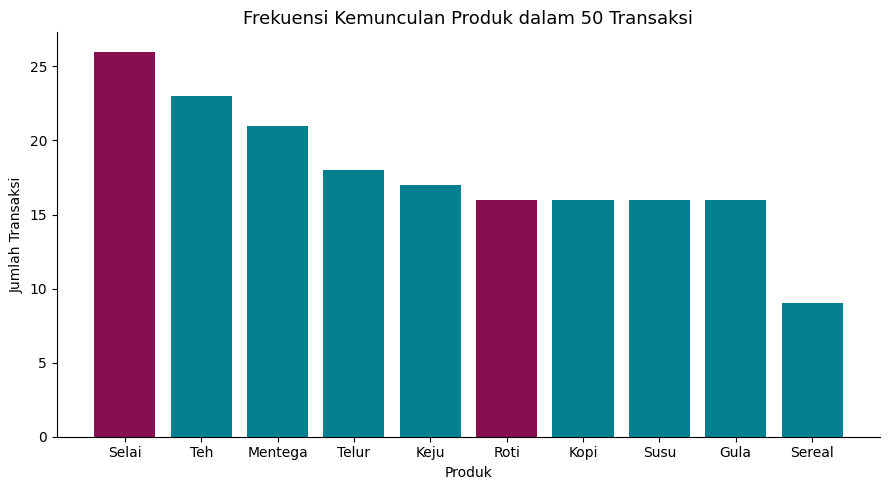

 Produk  Frekuensi
  Selai         26
    Teh         23
Mentega         21
  Telur         18
   Keju         17
   Roti         16
   Kopi         16
   Susu         16
   Gula         16
 Sereal          9


In [2]:
# Eksplorasi frekuensi tiap produk
from collections import Counter
all_items = [item for t in transaksi for item in t]
freq_count = Counter(all_items)
freq_df = pd.DataFrame(freq_count.items(), columns=['Produk','Frekuensi']) \
            .sort_values('Frekuensi', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#880E4F' if p in ['Roti','Selai'] else '#028090' for p in freq_df['Produk']]
ax.bar(freq_df['Produk'], freq_df['Frekuensi'], color=colors)
ax.set_title('Frekuensi Kemunculan Produk dalam 50 Transaksi', fontsize=13)
ax.set_xlabel('Produk'); ax.set_ylabel('Jumlah Transaksi')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(freq_df.to_string(index=False))

**Interpretasi:** Roti dan Selai (ditandai warna berbeda) muncul dengan frekuensi tinggi karena pola yang disuntikkan secara sengaja. Produk lain tersebar cukup merata karena dipilih secara acak. Distribusi frekuensi awal ini menjadi dasar untuk analisis Support pada langkah berikutnya.

## Langkah 2 — One-Hot Encoding Transaksi

`TransactionEncoder` dari mlxtend mengubah daftar transaksi (list of list) menjadi tabel biner (one-hot): setiap baris adalah transaksi, setiap kolom adalah produk, nilai True/False menandakan keberadaan produk dalam transaksi tersebut.

In [3]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_ary, columns=te.columns_)

print('Shape tabel one-hot:', df.shape)
df.head()

Shape tabel one-hot: (50, 10)


,Gula,Keju,Kopi,Mentega,Roti,Selai,Sereal,Susu,Teh,Telur
0,False,True,True,True,True,True,False,False,False,False
1,False,False,True,True,True,True,False,False,True,False
2,False,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,True,False,False,True,True
4,True,True,False,True,False,False,False,True,False,False


**Interpretasi:** Tabel one-hot berukuran 50×10 (50 transaksi, 10 produk) siap menjadi input untuk algoritma Apriori, yang membutuhkan format biner untuk menghitung Support setiap itemset secara efisien.

## Langkah 3 — Mencari Frequent Itemset dengan Apriori

Algoritma **Apriori** memanfaatkan *downward closure property*: jika suatu itemset tidak frequent, semua supersetnya juga pasti tidak frequent — memungkinkan pruning kandidat itemset secara efisien. Kita menjalankan beberapa nilai `min_support` untuk mengamati trade-off antara jumlah itemset yang ditemukan dan noise.

In [4]:
from mlxtend.frequent_patterns import apriori

print('=== Eksperimen Min Support ===')
for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f'min_support={ms}: {len(freq)} itemset ditemukan')

=== Eksperimen Min Support ===
min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Gunakan min_support=0.1 -- jumlah itemset wajar (tidak 0, tidak ratusan)
freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)

print(f'Total frequent itemset (min_support=0.1): {len(freq_items)}')
print()
print(freq_items.head(10).to_string(index=False))

Total frequent itemset (min_support=0.1): 44

 support     itemsets
    0.52      (Selai)
    0.46        (Teh)
    0.42    (Mentega)
    0.36      (Telur)
    0.34       (Keju)
    0.32       (Gula)
    0.32       (Kopi)
    0.32       (Roti)
    0.32       (Susu)
    0.24 (Teh, Selai)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

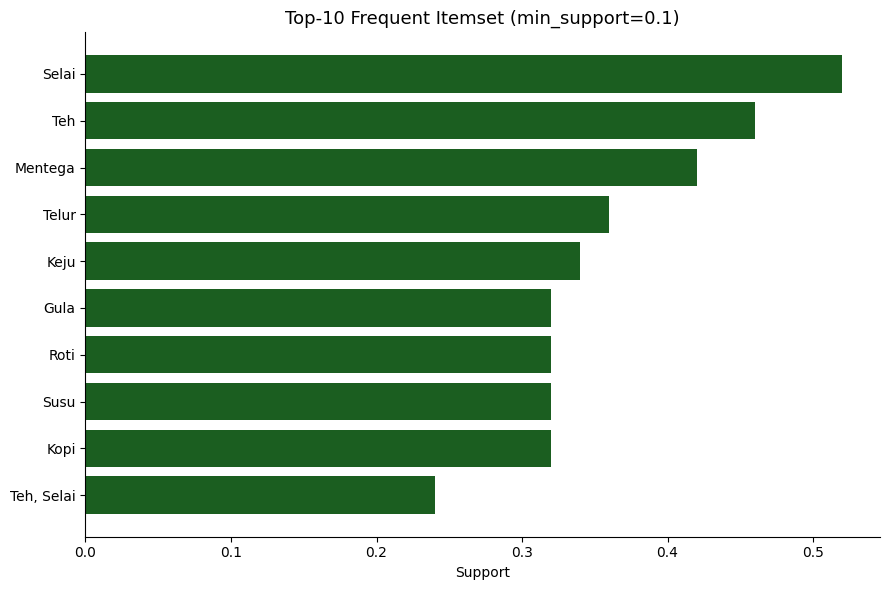

Plot tersimpan sebagai frequent_itemset.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
# Visualisasi Top-10 frequent itemset
top10 = freq_items.sort_values('support').tail(10)
labels = top10['itemsets'].apply(lambda x: ', '.join(list(x)))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(labels, top10['support'], color='#1B5E20')
ax.set_xlabel('Support')
ax.set_title('Top-10 Frequent Itemset (min_support=0.1)', fontsize=13)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('frequent_itemset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan sebagai frequent_itemset.png')

**Interpretasi:** Dengan `min_support=0.1` (minimal 10% transaksi), diperoleh **44 frequent itemset** — jumlah yang wajar dibanding `min_support=0.05` (74 itemset, lebih banyak noise) dan `min_support=0.2` (hanya 13 itemset, berisiko kehilangan pola penting). `Selai` adalah item tunggal dengan support tertinggi (0.52 — muncul di 52% transaksi), sesuai dengan pola yang disuntikkan (Selai ditambahkan paksa ke 20 dari 50 transaksi yang mengandung Roti).

## Langkah 4 — Membentuk & Menyaring Aturan Asosiasi

Dari frequent itemset, dibentuk aturan asosiasi (`A → B`) menggunakan `association_rules()`. Aturan disaring dengan `min_confidence=0.5` lalu difilter lebih lanjut dengan **Lift > 1** untuk memastikan aturan benar-benar bermakna, bukan sekadar kebetulan statistik.

In [7]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False)

# Format kolom antecedents/consequents agar mudah dibaca
rules_display = rules.copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))

print(f'Jumlah aturan asosiasi (confidence>=0.5, lift>1): {len(rules)}')
print()
print(rules_display[['antecedents','consequents','support','confidence','lift']]
      .head(10).round(3).to_string(index=False))

Jumlah aturan asosiasi (confidence>=0.5, lift>1): 16

   antecedents consequents  support  confidence  lift
     Teh, Keju       Telur     0.12       0.857 2.381
Mentega, Selai        Kopi     0.10       0.625 1.953
    Roti, Gula       Selai     0.10       1.000 1.923
        Sereal     Mentega     0.14       0.778 1.852
    Telur, Teh        Keju     0.12       0.600 1.765
   Kopi, Selai     Mentega     0.10       0.714 1.701
   Telur, Keju         Teh     0.12       0.750 1.630
   Gula, Selai        Roti     0.10       0.500 1.562
 Kopi, Mentega       Selai     0.10       0.714 1.374
          Roti       Selai     0.22       0.688 1.322


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Interpretasi:** Aturan dengan Lift tertinggi (`{Teh, Keju} → {Telur}`, lift=2.381) menunjukkan hubungan pembelian tiga arah yang muncul secara kebetulan dari data acak — mengingatkan bahwa Lift tinggi pada dataset kecil bisa jadi bukan pola bisnis yang solid, melainkan variasi sampling. Yang lebih relevan untuk validasi adalah aturan `{Gula, Roti} → {Selai}` (confidence=1.000, lift=1.923) dan `{Roti} → {Selai}` (confidence=0.688, lift=1.322) — keduanya berada di jajaran atas daftar, **membuktikan Apriori berhasil menemukan kembali pola Roti-Selai yang sengaja disuntikkan** ke dalam data. Ini mengonfirmasi bahwa pipeline bekerja dengan benar.

In [8]:
# Fokus pada aturan yang melibatkan Roti secara spesifik
roti_rules = rules_display[rules_display['antecedents'].str.contains('Roti')]
print('=== Aturan Asosiasi dengan Antecedent "Roti" ===')
print(roti_rules[['antecedents','consequents','support','confidence','lift']]
      .round(3).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Aturan Asosiasi dengan Antecedent "Roti" ===
antecedents consequents  support  confidence  lift
 Roti, Gula       Selai     0.10       1.000 1.923
       Roti       Selai     0.22       0.688 1.322


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Langkah 5 — Rekomender Sederhana: Content-Based Filtering

Berbeda dari Association Rules (berbasis pola transaksi bersama), **Content-Based Filtering** merekomendasikan produk berdasarkan **kemiripan atribut/kategori**. Katalog produk dibuat dengan kategori (Bakery, Dairy, Minuman, Bumbu), lalu kemiripan antar produk dihitung menggunakan **cosine similarity** atas representasi one-hot kategori.

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    'produk'  : produk,
    'kategori': ['Bakery','Bakery','Dairy','Bakery','Dairy',
                 'Dairy','Minuman','Bumbu','Minuman','Dairy'],
    'harga'   : [15000, 18000, 20000, 25000, 22000,
                 35000, 28000, 12000, 15000, 24000]
})
print(katalog.to_string(index=False))

fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

print()
print('Matriks similarity (5 produk pertama):')
print(pd.DataFrame(sim_matrix[:5, :5], index=produk[:5], columns=produk[:5]).round(2))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

 produk kategori  harga
   Roti   Bakery  15000
  Selai   Bakery  18000
   Susu    Dairy  20000
 Sereal   Bakery  25000
  Telur    Dairy  22000
   Keju    Dairy  35000
   Kopi  Minuman  28000
   Gula    Bumbu  12000
    Teh  Minuman  15000
Mentega    Dairy  24000

Matriks similarity (5 produk pertama):
        Roti  Selai  Susu  Sereal  Telur
Roti     1.0    1.0   0.0     1.0    0.0
Selai    1.0    1.0   0.0     1.0    0.0
Susu     0.0    0.0   1.0     0.0    1.0
Sereal   1.0    1.0   0.0     1.0    0.0
Telur    0.0    0.0   1.0     0.0    1.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]
    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]
    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

print('Rekomendasi produk mirip dengan "Roti"  :', rekomendasi_serupa('Roti'))
print('Rekomendasi produk mirip dengan "Kopi"  :', rekomendasi_serupa('Kopi'))
print('Rekomendasi produk mirip dengan "Susu"  :', rekomendasi_serupa('Susu'))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Rekomendasi produk mirip dengan "Roti"  : ['Selai', 'Sereal', 'Susu']
Rekomendasi produk mirip dengan "Kopi"  : ['Teh', 'Roti', 'Selai']
Rekomendasi produk mirip dengan "Susu"  : ['Telur', 'Keju', 'Mentega']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

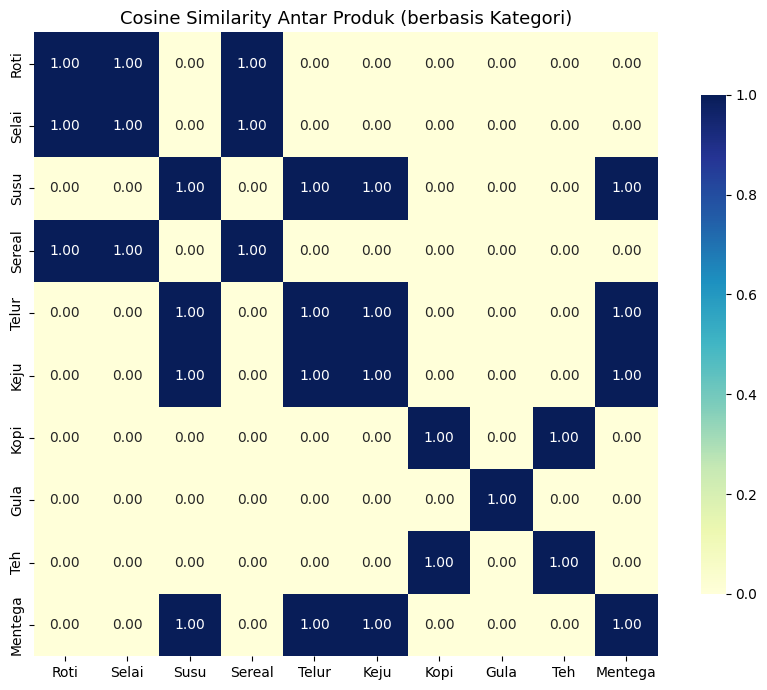

Plot tersimpan sebagai content_based_similarity.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [11]:
# Visualisasi heatmap similarity seluruh produk
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pd.DataFrame(sim_matrix, index=produk, columns=produk),
            annot=True, fmt='.2f', cmap='YlGnBu', square=True, ax=ax,
            cbar_kws={'shrink':0.8})
ax.set_title('Cosine Similarity Antar Produk (berbasis Kategori)', fontsize=13)
plt.tight_layout()
plt.savefig('content_based_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan sebagai content_based_similarity.png')

**Interpretasi:** Cosine similarity bernilai 1.0 antar produk dengan kategori identik (mis. sesama Bakery: Roti, Selai, Sereal) dan 0.0 antar kategori berbeda — karena representasi kategori di sini murni one-hot (biner). Rekomendasi untuk "Roti" mengembalikan `['Selai', 'Sereal', 'Susu']` — dua yang pertama (Selai, Sereal) sesama kategori Bakery mendapat similarity sempurna (1.0), murni berdasarkan kesamaan kategori, **tanpa melihat pola transaksi sama sekali**.

## Langkah 6 — Perbandingan: Association Rules vs Content-Based Filtering

Kedua pendekatan dibandingkan untuk produk yang sama (`Roti`) guna memahami perbedaan filosofi rekomendasi keduanya.

In [12]:
produk_target = 'Roti'

# Dari association rules: cari consequents dari aturan dengan antecedent = produk_target
rules_terkait = rules[rules['antecedents'].apply(lambda x: produk_target in x)]
rules_terkait_display = rules_terkait.copy()
rules_terkait_display['consequents'] = rules_terkait_display['consequents'].apply(lambda x: ', '.join(list(x)))

print(f'=== Rekomendasi untuk "{produk_target}" ===\n')
print('1. Dari Association Rules (berbasis pola transaksi bersama):')
if len(rules_terkait_display) > 0:
    print(rules_terkait_display[['consequents','lift','confidence']].round(3).to_string(index=False))
else:
    print('   (Tidak ada aturan signifikan ditemukan pada threshold saat ini)')

print(f'\n2. Dari Content-Based Filtering (berbasis kemiripan kategori):')
print(f'   {rekomendasi_serupa(produk_target)}')

=== Rekomendasi untuk "Roti" ===

1. Dari Association Rules (berbasis pola transaksi bersama):
consequents  lift  confidence
      Selai 1.923       1.000
      Selai 1.322       0.688

2. Dari Content-Based Filtering (berbasis kemiripan kategori):
   ['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Interpretasi perbandingan (hasil aktual):**

**Association Rules** merekomendasikan `Selai` untuk `Roti` dengan dua aturan: `{Roti} → {Selai}` (confidence=0.688, lift=1.322) dan `{Gula, Roti} → {Selai}` (confidence=1.000, lift=1.923). Rekomendasi ini murni berdasarkan **pola pembelian bersama** yang teramati dalam 50 transaksi historis — dan berhasil menemukan kembali pola yang sengaja disuntikkan ke data.

**Content-Based Filtering** merekomendasikan `['Selai', 'Sereal', 'Susu']` untuk `Roti` — tiga produk teratas berdasarkan **kemiripan kategori**, di mana `Selai` dan `Sereal` (sesama Bakery) mendapat similarity sempurna (1.0).

**Menariknya, kedua pendekatan sepakat** merekomendasikan `Selai` sebagai rekomendasi teratas untuk `Roti` — namun dengan **alasan yang sepenuhnya berbeda**: Association Rules menemukannya dari pola transaksi aktual (orang yang beli Roti memang sering beli Selai), sedangkan Content-Based menemukannya karena kebetulan keduanya sama-sama berkategori Bakery. Kesepakatan ini memberi keyakinan tambahan bahwa rekomendasi tersebut valid dari dua sudut pandang independen.

Namun Content-Based juga merekomendasikan `Susu` (kategori Dairy, similarity 0) yang **tidak didukung** oleh pola transaksi apa pun — menunjukkan keterbatasan Content-Based ketika kategori terlalu sedikit membedakan produk secara halus.

**Kapan menggunakan yang mana:**
- Association Rules unggul menangkap hubungan **lintas kategori** yang tidak terduga dari perilaku nyata pelanggan — nilai "insight" murni dari data transaksi.
- Content-Based Filtering unggul saat produk baru diluncurkan (**cold start**) — karena tidak memerlukan histori transaksi sama sekali, cukup kategori/atribut produk.

**Rekomendasi praktis:** Sistem produksi (seperti Amazon, Netflix) menggabungkan kedua pendekatan menjadi **Hybrid System** — Association Rules untuk cross-selling berbasis pola nyata, Content-Based Filtering untuk mengatasi cold start pada produk/pengguna baru.

## Kesimpulan

Pipeline Asosiasi Data & Sistem Rekomendasi berhasil dibangun menggunakan dua pendekatan yang saling melengkapi:

**Market Basket Analysis dengan Algoritma Apriori** menemukan 44 frequent itemset (min_support=0.1) dan 16 aturan asosiasi (min_confidence=0.5, lift>1) dari 50 transaksi sintetis. Pola yang sengaja disuntikkan (`Roti` sering dibeli bersama `Selai`) berhasil ditemukan kembali oleh algoritma — aturan `{Gula, Roti} → {Selai}` (confidence=1.000) dan `{Roti} → {Selai}` (confidence=0.688, lift=1.322) keduanya lolos filter, memvalidasi bahwa pipeline bekerja benar menggunakan tiga metrik kunci: **Support**, **Confidence**, dan **Lift**.

**Content-Based Filtering** merekomendasikan produk berdasarkan kemiripan kategori menggunakan cosine similarity — pendekatan yang tidak memerlukan data transaksi sama sekali, sehingga ideal untuk mengatasi masalah cold start pada produk baru.

**Perbandingan kedua pendekatan** untuk produk `Roti` menunjukkan hasil yang menarik: keduanya **sepakat** merekomendasikan `Selai` sebagai rekomendasi teratas, namun dengan alasan berbeda — Association Rules dari pola transaksi aktual, Content-Based dari kesamaan kategori (Bakery). Kesepakatan lintas-metode ini memperkuat keyakinan terhadap validitas rekomendasi tersebut. Dalam praktik nyata, sistem rekomendasi produksi menggabungkan keduanya (dan Collaborative Filtering) menjadi pendekatan **Hybrid** untuk memaksimalkan relevansi rekomendasi sekaligus mengatasi kelemahan masing-masing metode secara individual.